<a href="https://colab.research.google.com/github/manubastidas/programacionCientifica/blob/manubastidas-patch-1/redes_neuronales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Redes Neuronales y Descenso de Gradiente

**Programación Científica 2026-1 · Universidad Nacional de Colombia**  
mbastidaso@unal.edu.co


[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/)

In [1]:
!sudo apt-get update
!sudo apt-get install texlive-latex-extra texlive-fonts-recommended dvipng cm-super

import matplotlib.pyplot as plt

import matplotlib.colors as mcolors

import numpy as np

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "font.size": 16,

    # Ejes y Ticks
    "axes.labelsize": 16,
    "axes.titlesize": 18,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,
    "xtick.direction": "in",
    "ytick.direction": "in",

    # Grid
    "grid.color"    : "gray",
    "grid.linewidth": 0.3,
    "grid.alpha"    : 0.3,
    "grid.linestyle": "--",

    # Estetica
    "figure.dpi"        : 120,
    "axes.spines.top"   : False,
    "axes.spines.right" : False,
    "savefig.bbox"      : "tight",
    "savefig.dpi"       : 300,
})

import jax
import jax.numpy as jnp
from jax import grad, jit, vmap

print('Configuracion OK')

Get:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:2 https://cli.github.com/packages stable InRelease [3,917 B]
Get:3 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Hit:4 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:5 https://cli.github.com/packages stable/main amd64 Packages [355 B]
Get:6 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:7 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Get:8 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Hit:9 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:10 http://archive.ubuntu.com/ubuntu jammy-updates/restricted amd64 Packages [7,489 kB]
Get:11 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:12 http://archive.ubuntu.com/ubuntu jammy-updates/universe amd64 Packages [1,611 kB]
Get:13 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 Packages [4,357 kB]
Get:

## El hilo del curso

En todos los métodos anteriores buscamos una aproximación de la forma

$$\hat{f}(x) = \sum_{i=1}^n c_i\,\phi_i(x)$$

donde las **bases** $\phi_i$ estaban fijas (monomios, splines, Bézier) y solo optimizábamos los **coeficientes** $c_i$.

En una red neuronal, los $\phi_i$ **también dependen de parámetros** que se aprenden de los datos. El precio: necesitamos optimizar una función de pérdida $\mathcal{L}(\theta)$ sobre todos los parámetros $\theta$ a la vez.

## 1. La función de pérdida como mínimos cuadrados

Dado un conjunto de datos $\{(x_i, y_i)\}_{i=1}^N$ con $y_i = f(x_i)$, definimos la pérdida cuadrática:

$${L}(\theta) = \frac{1}{N}\sum_{i=1}^N \bigl(y_i - \hat{f}(x_i;\theta)\bigr)^2 = \frac{1}{N}\|y - \hat{y}(\theta)\|^2$$

Para una **red lineal** $\hat{f}(x;\theta) = \theta^\top \phi(x)$ esto es exactamente mínimos cuadrados:

$${L}(\theta) = \frac{1}{N}\|y - A\theta\|^2, \qquad A_{ij} = \phi_j(x_i)$$

con mínimo en $\theta^* = (A^\top A)^{-1} A^\top y$ (ecuaciones normales).

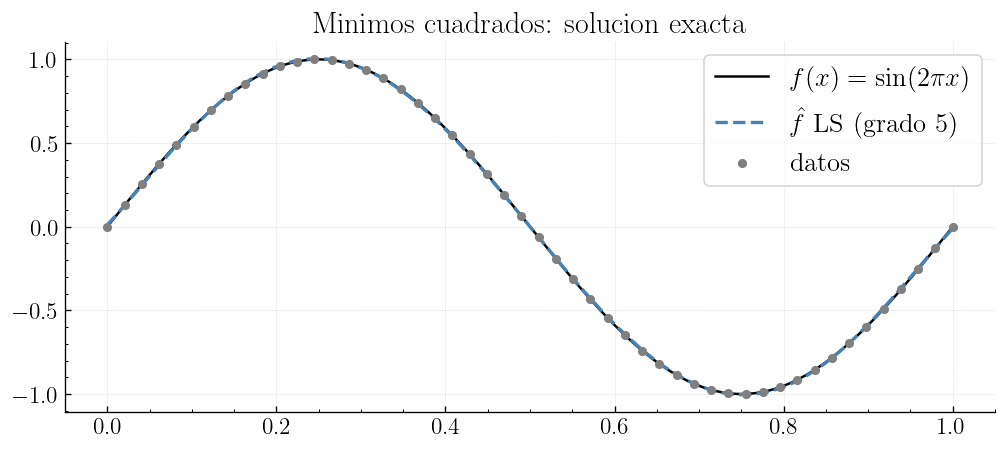

Loss minimos cuadrados: 2.28e-05


In [2]:
# Funcion objetivo: f(x) = sin(2*pi*x)
np.random.seed(0)
N = 50
xs = np.linspace(0, 1, N)
ys = np.sin(2 * np.pi * xs)

# Red lineal: phi_j(x) = x^j, j = 0,...,p-1
p = 6
A = np.vander(xs, p, increasing=True)  # A[i,j] = xs[i]^j

# Minimos cuadrados: solucion exacta
theta_ls, _, _, _ = np.linalg.lstsq(A, ys, rcond=None)

x_cont = np.linspace(0, 1, 300)
A_cont = np.vander(x_cont, p, increasing=True)
y_ls   = A_cont @ theta_ls

plt.figure(figsize=(10, 4))
plt.plot(x_cont, np.sin(2 * np.pi * x_cont), 'k-', lw=1.5, label=r'$f(x) = \sin(2\pi x)$')
plt.plot(x_cont, y_ls, '--', color='steelblue', lw=2,
         label=rf'$\hat{{f}}$ LS (grado {p-1})')
plt.scatter(xs, ys, s=20, color='gray', zorder=5, label='datos')
plt.legend()
plt.title('Minimos cuadrados: solucion exacta')
plt.grid(True)
plt.show()

loss_ls = np.mean((ys - A @ theta_ls)**2)
print(f'Loss minimos cuadrados: {loss_ls:.2e}')

## 2. Descenso de gradiente sobre la pérdida cuadrática

En lugar de resolver las ecuaciones normales, usamos el **descenso de gradiente**:

$$\theta_{k+1} = \theta_k - \eta\,\nabla_\theta{L}(\theta_k)$$

Para la pérdida cuadrática lineal el gradiente es:

$$\nabla_\theta{L}(\theta) = \frac{2}{N}A^\top(A\theta - y)$$

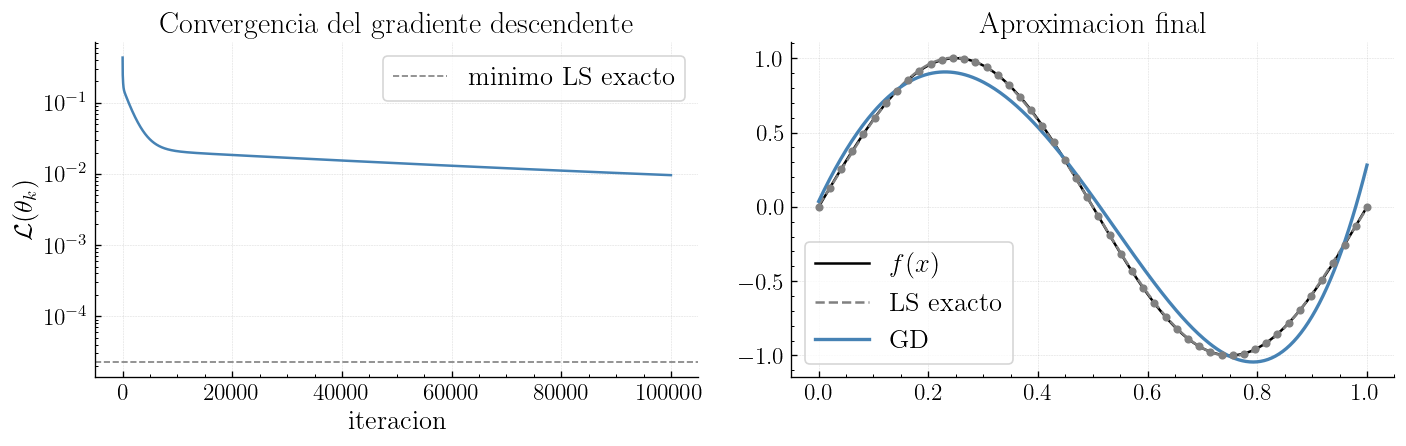

Loss GD: 9.64e-03  |  Loss LS exacto: 2.28e-05


In [3]:
# Gradiente exacto de L(theta) = (1/N) ||y - A theta||^2
def grad_loss_lineal(theta, A, y):
    residuo = A @ theta - y
    return (2 / len(y)) * A.T @ residuo

eta =2e-1

# Descenso de gradiente
theta = np.zeros(p)
n_iter = 100000
historico = []

for _ in range(n_iter):
    theta = theta - eta * grad_loss_lineal(theta, A, ys)
    historico.append(np.mean((ys - A @ theta)**2))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].semilogy(historico, color='steelblue', lw=1.5)
axes[0].axhline(loss_ls, color='gray', ls='--', lw=1, label='minimo LS exacto')
axes[0].set_xlabel('iteracion'); axes[0].set_ylabel(r'$\mathcal{L}(\theta_k)$')
axes[0].set_title('Convergencia del gradiente descendente')
axes[0].legend()
axes[0].grid(True)

y_gd = A_cont @ theta
axes[1].plot(x_cont, np.sin(2 * np.pi * x_cont), 'k-', lw=1.5, label=r'$f(x)$')
axes[1].plot(x_cont, y_ls, '--', color='gray', lw=1.5, label='LS exacto')
axes[1].plot(x_cont, y_gd, '-', color='steelblue', lw=2, label='GD')
axes[1].scatter(xs, ys, s=15, color='gray', zorder=5)
axes[1].legend(); axes[1].set_title('Aproximacion final')
axes[1].grid(True)

plt.tight_layout()
plt.show()

print(f'Loss GD: {historico[-1]:.2e}  |  Loss LS exacto: {loss_ls:.2e}')

## 3. Red neuronal de una capa oculta

Ahora $\hat{f}$ es **no lineal** en $\theta$:

$$\hat{f}(x;\theta) = W_2\,\sigma(W_1 x + \mathbf{b}_1) + b_2$$

con $\sigma(z) = \tanh(z)$. Los parámetros son $\theta = \{W_1, \mathbf{b}_1, W_2, b_2\}$.

La pérdida ya no es convexa, pero el gradiente descendente sigue funcionando localmente.
JAX calcula $\nabla_\theta {L}$ automáticamente via backpropagation.

In [4]:
# Arquitectura: 1 -> m -> 1
m = 20  # neuronas ocultas

def init_params(m, key):
    k1, k2, k3, k4 = jax.random.split(key, 4)
    return {
        'W1': jax.random.normal(k1, (m, 1)) * 0.1,
        'b1': jnp.zeros((m,)),
        'W2': jax.random.normal(k3, (1, m)) * 0.1,
        'b2': jnp.zeros((1,)),
    }

def red(params, x):
    # Forward pass
    h = jnp.tanh(params['W1'] @ jnp.array([x]) + params['b1'])  # (m,)
    return (params['W2'] @ h + params['b2'])[0]                  # escalar

def loss(params, xs, ys):
    y_hat = vmap(lambda x: red(params, x))(xs)
    return jnp.mean((ys - y_hat) ** 2)

# Verificar forward pass
key = jax.random.PRNGKey(42)
params = init_params(m, key)
xs_jax = jnp.array(xs)
ys_jax = jnp.array(ys)

print(f'Loss inicial: {loss(params, xs_jax, ys_jax):.4f}')
print(f'Parametros totales: {sum(v.size for v in jax.tree_util.tree_leaves(params))}')

Loss inicial: 0.4861
Parametros totales: 61


## 4. Backpropagation con JAX

`jax.grad(loss)` calcula $\nabla_\theta {L}$ exactamente via autodiff en modo reverso.
Una llamada a `grad` corresponde a una pasada backward sobre el grafo computacional de `loss`.

In [5]:
grad_loss = jit(grad(loss))  # backward pass compilado

# Verificar que los gradientes tienen la misma forma que los parametros
grads = grad_loss(params, xs_jax, ys_jax)
for k in params:
    print(f'grad[{k}]: shape {grads[k].shape},  norma {jnp.linalg.norm(grads[k]):.4f}')

grad[W1]: shape (20, 1),  norma 0.1354
grad[b1]: shape (20,),  norma 0.0064
grad[W2]: shape (1, 20),  norma 0.1086
grad[b2]: shape (1,),  norma 0.0126


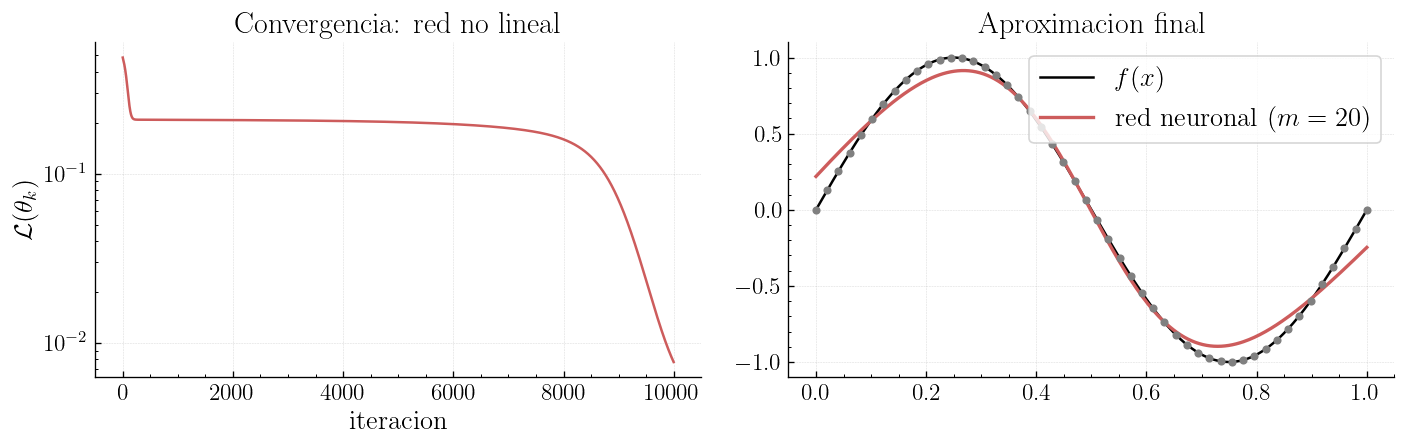

Loss final: 7.72e-03


In [6]:
# Descenso de gradiente sobre la red no lineal
eta = 0.05
n_iter = 10000
historico_nn = []

params = init_params(m, key)

for k in range(n_iter):
    grads = grad_loss(params, xs_jax, ys_jax)
    # Actualizar todos los parametros: theta <- theta - eta * grad
    params = jax.tree_util.tree_map(lambda p, g: p - eta * g, params, grads)
    historico_nn.append(float(loss(params, xs_jax, ys_jax)))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].semilogy(historico_nn, color='indianred', lw=1.5)
axes[0].set_xlabel('iteracion'); axes[0].set_ylabel(r'$\mathcal{L}(\theta_k)$')
axes[0].set_title('Convergencia: red no lineal')
axes[0].grid(True)

x_cont_jax = jnp.linspace(0, 1, 300)
y_nn = vmap(lambda x: red(params, x))(x_cont_jax)

axes[1].plot(x_cont, np.sin(2 * np.pi * x_cont), 'k-', lw=1.5, label=r'$f(x)$')
axes[1].plot(np.array(x_cont_jax), np.array(y_nn), '-', color='indianred', lw=2,
             label=f'red neuronal ($m={m}$)')
axes[1].scatter(xs, ys, s=15, color='gray', zorder=5)
axes[1].legend(); axes[1].set_title('Aproximacion final')
axes[1].grid(True)

plt.tight_layout()
plt.show()

print(f'Loss final: {historico_nn[-1]:.2e}')

### Ejercicio 2

Completen la siguiente celda para comparar redes con $m \in \{2, 5, 20, 50\}$ neuronas.
Para cada una, entrenen 2000 iteraciones y grafiquen la pérdida final vs $m$.

¿A partir de qué $m$ la red aproxima bien $\sin(2\pi x)$?

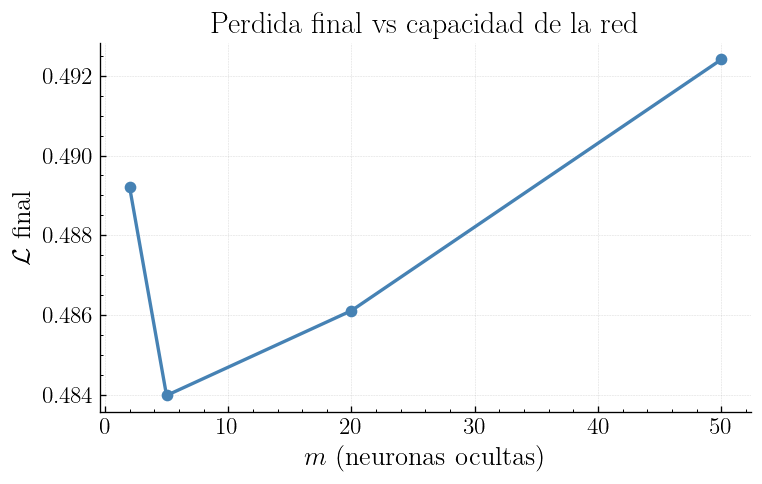

In [7]:
ms = [2, 5, 20, 50]
losses_finales = []

for m_i in ms:
    params_i = init_params(m_i, key)
    grad_loss_i = jit(grad(loss))

    for _ in range(2000):
        # completar: actualizar params_i con gradiente descendente
        pass

    losses_finales.append(float(loss(params_i, xs_jax, ys_jax)))

plt.figure(figsize=(7, 4))
plt.plot(ms, losses_finales, 'o-', color='steelblue', lw=2)
plt.xlabel(r'$m$ (neuronas ocultas)')
plt.ylabel(r'$\mathcal{L}$ final')
plt.title('Perdida final vs capacidad de la red')
plt.grid(True)
plt.show()